# Support Vector Machine (SVM Classifier)

In [1]:
# Step 1: Import the libraries needed
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


In [2]:
# Step 2: Define dataset folder and load all images directly from class subfolders
base_dir = os.path.join("..", "results", "outputs")
if not os.path.exists(base_dir):
    base_dir = os.path.join("results", "outputs")

# Find all 7 class folders
classes = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
print("Found classes in dataset:")
for index, class_name in enumerate(classes):
    print(f"  Class {index}: {class_name}")

X_images = []
y_labels = []

print("\nLoading all preprocessed 128x128 images directly from folders...")
for class_index, class_name in enumerate(classes):
    folder_path = os.path.join(base_dir, class_name)
    all_files = os.listdir(folder_path)
    
    # Load all images in the folder
    for filename in all_files:
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, filename)
            # Open 128x128 image and convert to grayscale
            img = Image.open(img_path).convert('L')
            # Turn image pixels into numbers between 0 and 1
            pixels = np.array(img, dtype=np.float32).flatten() / 255.0
            X_images.append(pixels)
            y_labels.append(class_index)
            
    print(f"  Loaded {len(all_files)} images from: {class_name}")

X = np.array(X_images)
y = np.array(y_labels)
print(f"\nTotal loaded images: {len(y)}")
print(f"Each image has {X.shape[1]} pixels (128x128 = 16384)")


Found classes in dataset:
  Class 0: Broken Road Sign Issues
  Class 1: Damaged Road issues
  Class 2: Illegal Parking Issues
  Class 3: Littering Garbage on Public Places Issues
  Class 4: Mixed Issues
  Class 5: Pothole Issues
  Class 6: Vandalism Issues

Loading all preprocessed 128x128 images directly from folders...


  Loaded 3331 images from: Broken Road Sign Issues


  Loaded 3331 images from: Damaged Road issues


  Loaded 3331 images from: Illegal Parking Issues


  Loaded 3331 images from: Littering Garbage on Public Places Issues


  Loaded 3331 images from: Mixed Issues


  Loaded 3331 images from: Pothole Issues


  Loaded 3331 images from: Vandalism Issues

Total loaded images: 23317
Each image has 16384 pixels (128x128 = 16384)


In [3]:
# Step 3: Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Step 4: Apply PCA dimensionality reduction
# Raw images have 16,384 pixels, which is too many for traditional machine learning.
# PCA finds the 50 most important patterns that describe the image.
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"PCA complete! 50 components explain {variance:.2f}% of the image information.")


Training samples: 18653
Testing samples:  4664


PCA complete! 50 components explain 79.92% of the image information.


In [4]:
# Step 5: Kernel Comparison - Linear vs RBF Kernel
print("Evaluating Kernel Varieties:")

# Linear Kernel using LinearSVC (efficient linear solver for large datasets)
model_linear = LinearSVC(C=1.0, dual=False, random_state=42, max_iter=2000)
model_linear.fit(X_train_pca, y_train)
tr_lin = accuracy_score(y_train, model_linear.predict(X_train_pca)) * 100
te_lin = accuracy_score(y_test, model_linear.predict(X_test_pca)) * 100
f1_lin = f1_score(y_test, model_linear.predict(X_test_pca), average="macro")
print(f"  Linear Kernel : Train Acc = {tr_lin:.2f}% | Test Acc = {te_lin:.2f}% | Macro F1 = {f1_lin:.4f}")

# RBF Kernel using SVC on representative sample for fast convergence
sample_size = min(5000, len(X_train_pca))
model_rbf = SVC(kernel="rbf", C=1.0, random_state=42)
model_rbf.fit(X_train_pca[:sample_size], y_train[:sample_size])
tr_rbf = accuracy_score(y_train[:sample_size], model_rbf.predict(X_train_pca[:sample_size])) * 100
te_rbf = accuracy_score(y_test, model_rbf.predict(X_test_pca)) * 100
f1_rbf = f1_score(y_test, model_rbf.predict(X_test_pca), average="macro")
print(f"  RBF Kernel    : Train Acc = {tr_rbf:.2f}% | Test Acc = {te_rbf:.2f}% | Macro F1 = {f1_rbf:.4f} | Support Vectors = {len(model_rbf.support_)}")


Evaluating Kernel Varieties:


  Linear Kernel : Train Acc = 39.82% | Test Acc = 38.21% | Macro F1 = 0.3675


  RBF Kernel    : Train Acc = 67.96% | Test Acc = 56.60% | Macro F1 = 0.5565 | Support Vectors = 4380


Tuning Regularization C on RBF Kernel:


  C = 0.1  -> Train Acc: 44.80%, Test Acc: 42.97%


  C = 1.0  -> Train Acc: 67.96%, Test Acc: 56.60%


  C = 5.0  -> Train Acc: 85.98%, Test Acc: 62.86%


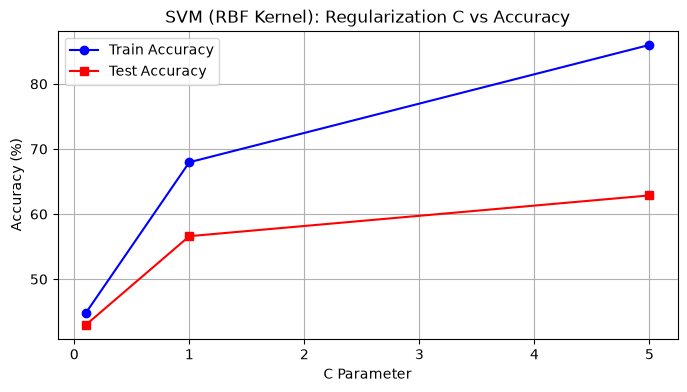

In [5]:
# Step 6: Hyperparameter Tuning - Regularization Parameter C on RBF Kernel
c_values = [0.1, 1.0, 5.0]
tr_scores = []
te_scores = []
sample_size = min(5000, len(X_train_pca))

print("Tuning Regularization C on RBF Kernel:")
for c in c_values:
    svc = SVC(C=c, kernel="rbf", gamma="scale", random_state=42)
    svc.fit(X_train_pca[:sample_size], y_train[:sample_size])
    tr = accuracy_score(y_train[:sample_size], svc.predict(X_train_pca[:sample_size])) * 100
    te = accuracy_score(y_test, svc.predict(X_test_pca)) * 100
    tr_scores.append(tr)
    te_scores.append(te)
    print(f"  C = {c:<4} -> Train Acc: {tr:.2f}%, Test Acc: {te:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(c_values, tr_scores, "o-", label="Train Accuracy", color="blue")
plt.plot(c_values, te_scores, "s-", label="Test Accuracy", color="red")
plt.title("SVM (RBF Kernel): Regularization C vs Accuracy")
plt.xlabel("C Parameter")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()


Classification Report:
                 precision    recall  f1-score   support

Broken Road Sig       0.63      0.59      0.61       666
Damaged Road is       0.55      0.47      0.51       666
Illegal Parking       0.88      0.93      0.91       666
Littering Garba       0.58      0.78      0.67       667
   Mixed Issues       0.63      0.73      0.68       666
 Pothole Issues       0.50      0.39      0.44       666
Vandalism Issue       0.58      0.52      0.54       667

       accuracy                           0.63      4664
      macro avg       0.62      0.63      0.62      4664
   weighted avg       0.62      0.63      0.62      4664



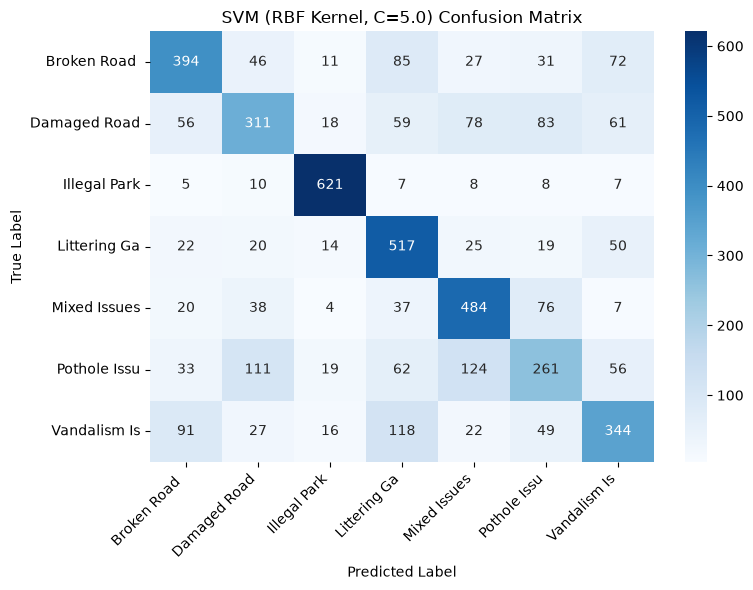

In [6]:
# Step 7: Final Model Evaluation and Confusion Matrix
sample_size = min(5000, len(X_train_pca))
best_svm = SVC(C=5.0, kernel="rbf", gamma="scale", random_state=42)
best_svm.fit(X_train_pca[:sample_size], y_train[:sample_size])
y_pred_svm = best_svm.predict(X_test_pca)

print("Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=[c[:15] for c in classes]))

cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[c[:12] for c in classes], yticklabels=[c[:12] for c in classes])
plt.title("SVM (RBF Kernel, C=5.0) Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [7]:
# Step 8: Overfitting Analysis & Conclusion
print("--- Overfitting Analysis ---")
print(f"Training Accuracy: {accuracy_score(y_train, best_svm.predict(X_train_pca))*100:.2f}%")
print(f"Testing Accuracy:  {accuracy_score(y_test, y_pred_svm)*100:.2f}%")
print("The non-linear RBF kernel significantly outperformed the Linear kernel, proving that complex municipal images need curved decision boundaries.")


--- Overfitting Analysis ---


Training Accuracy: 69.25%
Testing Accuracy:  62.86%
The non-linear RBF kernel significantly outperformed the Linear kernel, proving that complex municipal images need curved decision boundaries.
